# Liver Disease Data Analysis

An analysis covering data preprocessing, exploratory data analysis, visualization, and machine learning with scikit-learn.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Data Loading

In [2]:
import kagglehub
import os

path = kagglehub.dataset_download("priyankabarik/liver-diseases")
traincsv = os.path.join(path, "Training_Liver_Disease_Dataset.csv")
testcsv = os.path.join(path, "Testing_Liver_Disease_Dataset.csv")

df_train = pd.read_csv(traincsv)
df_test = pd.read_csv(testcsv)

print(f"Training set shape: {df_train.shape}")
print(f"Test set shape: {df_test.shape}")

Training set shape: (30000, 33)
Test set shape: (5500, 33)


## 2. Data Preprocessing

In [3]:
df_train['Source'] = 'Train'
df_test['Source'] = 'Test'
df = pd.concat([df_train, df_test], ignore_index=True)

print(f"Combined dataset shape: {df.shape}")
df.info()

Combined dataset shape: (35500, 33)
<class 'pandas.DataFrame'>
RangeIndex: 35500 entries, 0 to 35499
Data columns (total 33 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     35500 non-null  int64  
 1   Gender                  35500 non-null  str    
 2   Occupation              35500 non-null  str    
 3   BMI                     35500 non-null  float64
 4   Obesity_Class           35500 non-null  str    
 5   Waist_Circumference     35500 non-null  float64
 6   Diet_Quality            35500 non-null  str    
 7   Physical_Activity       35500 non-null  str    
 8   Sleep_Hours             35500 non-null  float64
 9   Smoking_Status          35500 non-null  str    
 10  Alcohol_Consumption     26582 non-null  str    
 11  Sym_Fatigue             35500 non-null  int64  
 12  Sym_Jaundice            35500 non-null  int64  
 13  Sym_Abdominal_Pain      35500 non-null  int64  
 14  Sym_Itching  

In [4]:
print("--- Missing Values ---")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found")

print("\n--- Basic Statistics ---")
df.describe()

--- Missing Values ---
Alcohol_Consumption    8918
Medication_History     7097
dtype: int64

--- Basic Statistics ---


,Age,BMI,Waist_Circumference,Sleep_Hours,Sym_Fatigue,Sym_Jaundice,Sym_Abdominal_Pain,Sym_Itching,Sym_Ascites,Sym_Dark_Urine,Sym_Weight_Loss,Comorb_Diabetes,Comorb_Hypertension,Comorb_Genetic_History,ALT,AST,Bilirubin,Albumin,Platelets,Alk_Phosphatase,GGT,Triglycerides,INR
count,35500.000000,35500.000000,35500.000000,35500.000000,35500.000000,35500.000000,35500.000000,35500.000000,35500.000000,35500.000000,35500.000000,35500.000000,35500.000000,35500.00000,35500.000000,35500.000000,35500.000000,35500.000000,35500.000000,35500.000000,35500.000000,35500.000000,35500.000000
mean,45.889944,26.084470,92.082944,7.004149,0.377718,0.115296,0.264930,0.186310,0.054451,0.240000,0.117183,0.290113,0.272282,0.13338,40.021761,37.243545,1.008983,4.187560,252.703268,89.988000,44.029465,161.775324,1.183064
std,15.291926,4.901165,12.616845,1.180853,0.484823,0.319383,0.441302,0.389362,0.226908,0.427089,0.321643,0.453821,0.445140,0.33999,18.193380,20.378930,0.660829,0.400625,64.557631,23.574152,32.725275,68.980296,0.349553
min,18.000000,16.000000,60.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,10.000000,10.000000,0.200000,2.500000,10.000000,50.000000,10.000000,60.000000,0.800000
25%,35.000000,22.700000,83.300000,6.200000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,26.350000,23.530000,0.590000,3.980000,210.000000,73.000000,21.000000,113.000000,0.970000
50%,46.000000,26.000000,92.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,36.830000,32.635000,0.900000,4.230000,254.000000,89.000000,37.000000,147.000000,1.100000
75%,56.000000,29.400000,100.600000,7.800000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.00000,51.540000,45.310000,1.250000,4.460000,297.000000,106.000000,56.000000,194.000000,1.250000
max,85.000000,45.000000,130.000000,10.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,120.000000,156.000000,4.500000,5.000000,420.000000,150.000000,270.000000,450.000000,2.640000


In [5]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

categorical_cols.remove('Liver_Disease_Class')
categorical_cols.remove('Source')

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Categorical columns: ['Gender', 'Occupation', 'Obesity_Class', 'Diet_Quality', 'Physical_Activity', 'Smoking_Status', 'Alcohol_Consumption', 'Medication_History']
Numerical columns: ['Age', 'BMI', 'Waist_Circumference', 'Sleep_Hours', 'Sym_Fatigue', 'Sym_Jaundice', 'Sym_Abdominal_Pain', 'Sym_Itching', 'Sym_Ascites', 'Sym_Dark_Urine', 'Sym_Weight_Loss', 'Comorb_Diabetes', 'Comorb_Hypertension', 'Comorb_Genetic_History', 'ALT', 'AST', 'Bilirubin', 'Albumin', 'Platelets', 'Alk_Phosphatase', 'GGT', 'Triglycerides', 'INR']


## 3. Exploratory Data Analysis

In [6]:
df_eda = df[df['Source'] == 'Train'].copy()

print("--- Target Variable Distribution ---")
print(df_eda['Liver_Disease_Class'].value_counts())

--- Target Variable Distribution ---
Liver_Disease_Class
Healthy Liver                     13500
Fatty Liver Disease (NAFLD)        9000
Alcoholic Liver Disease            3000
General Liver Disease Severity     2400
Liver Cirrhosis Risk               2100
Name: count, dtype: int64


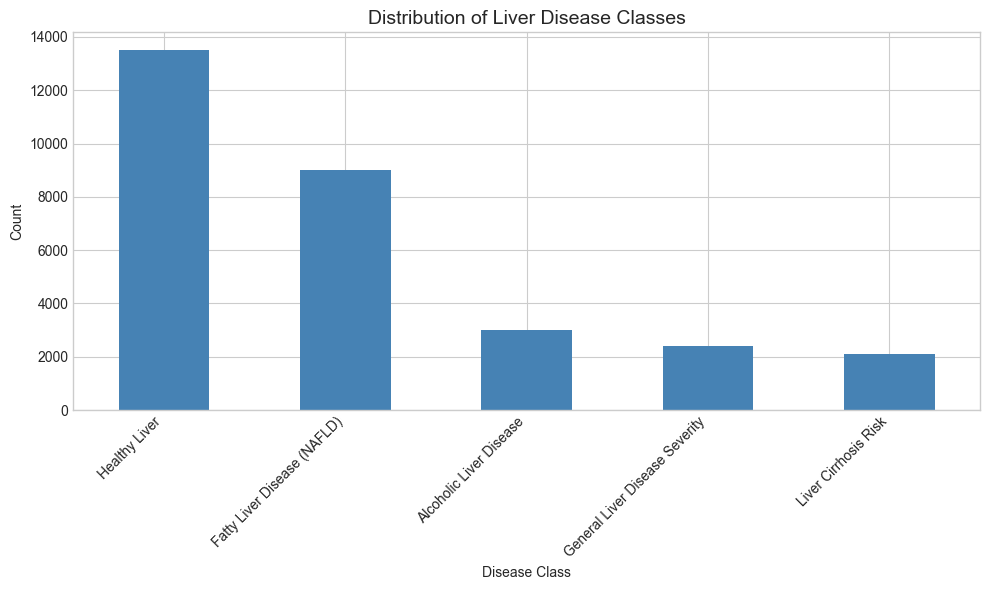

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
df_eda['Liver_Disease_Class'].value_counts().plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Distribution of Liver Disease Classes', fontsize=14)
ax.set_xlabel('Disease Class')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

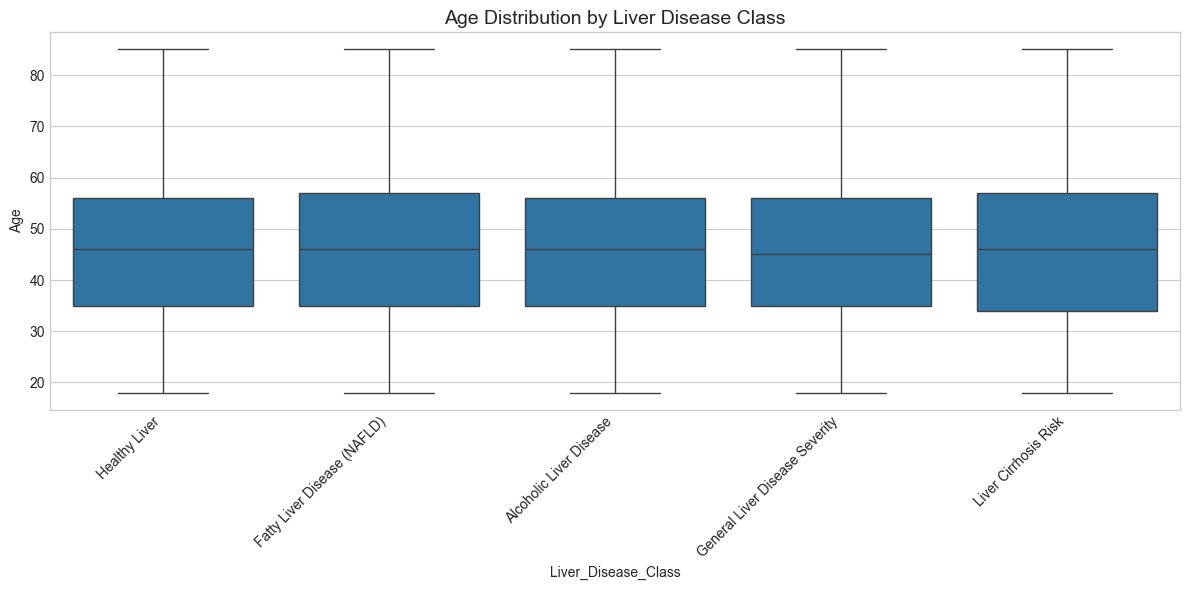

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df_eda, x='Liver_Disease_Class', y='Age', ax=ax)
ax.set_title('Age Distribution by Liver Disease Class', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

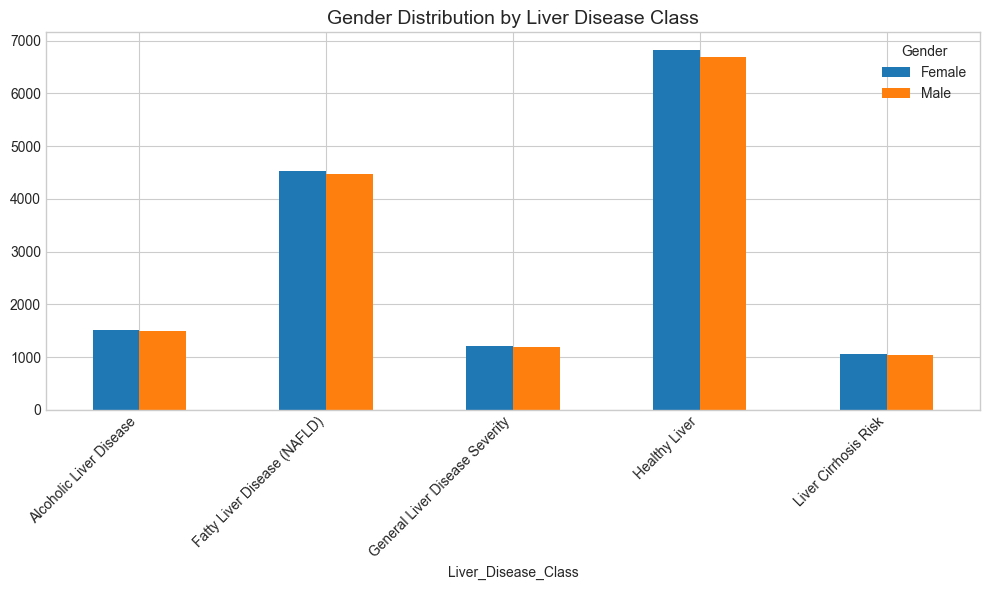

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
pd.crosstab(df_eda['Liver_Disease_Class'], df_eda['Gender']).plot(kind='bar', ax=ax)
ax.set_title('Gender Distribution by Liver Disease Class', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

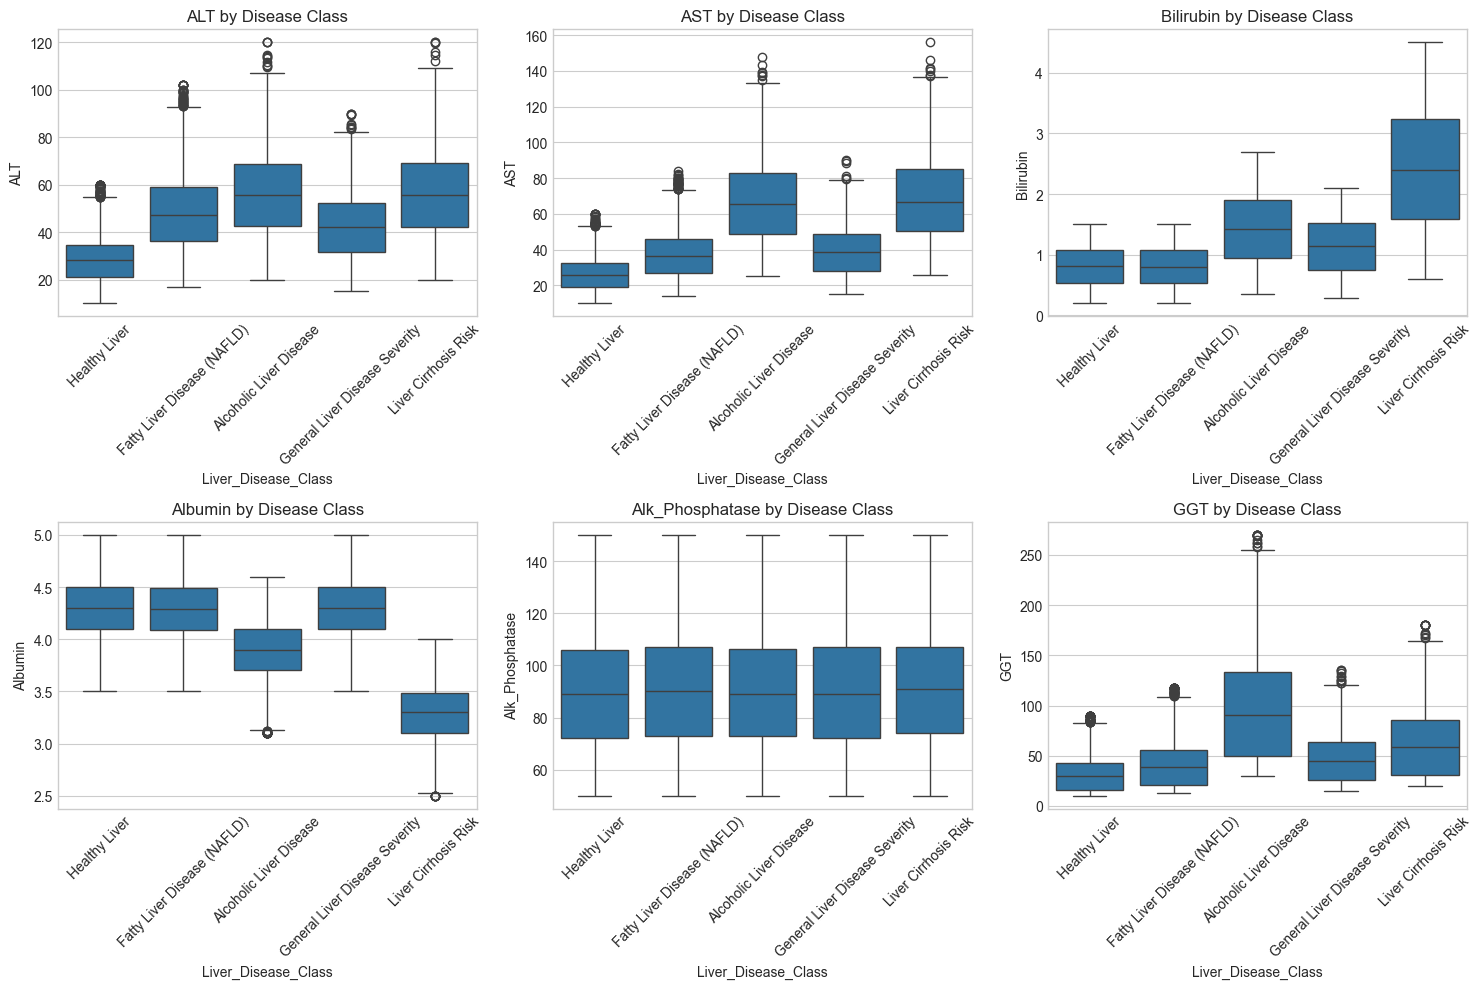

In [10]:
lab_values = ['ALT', 'AST', 'Bilirubin', 'Albumin', 'Alk_Phosphatase', 'GGT']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(lab_values):
    sns.boxplot(data=df_eda, x='Liver_Disease_Class', y=col, ax=axes[i])
    axes[i].set_title(f'{col} by Disease Class')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

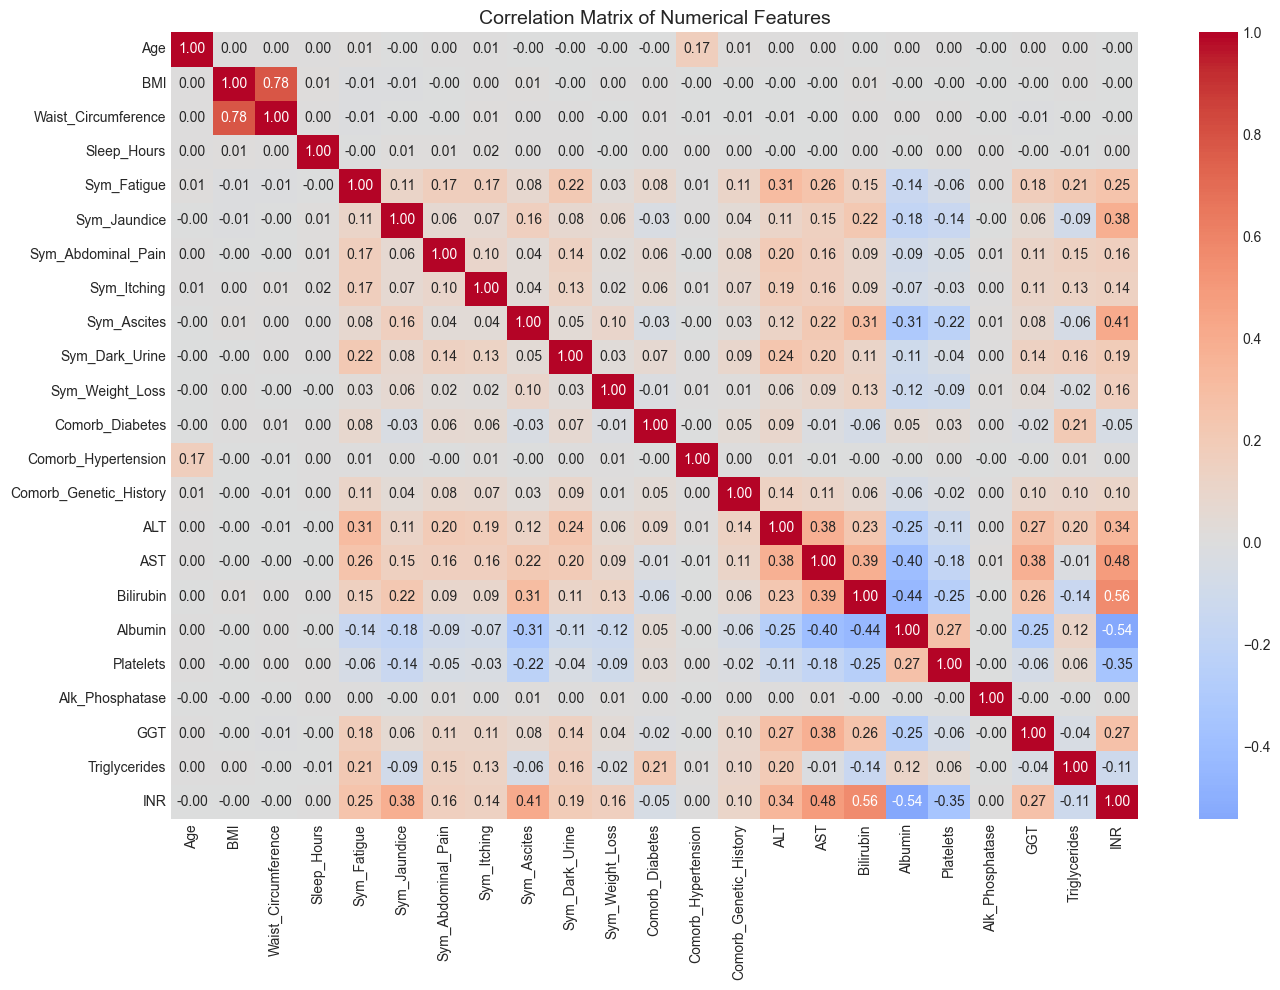

In [11]:
plt.figure(figsize=(14, 10))
corr_matrix = df_eda[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Machine Learning

In [12]:
df_ml = df[df['Source'] == 'Train'].copy()
df_ml = df_ml.drop('Source', axis=1)

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col])
    label_encoders[col] = le

le_target = LabelEncoder()
df_ml['Liver_Disease_Class_Encoded'] = le_target.fit_transform(df_ml['Liver_Disease_Class'])

print("Target classes:", le_target.classes_)

Target classes: ['Alcoholic Liver Disease' 'Fatty Liver Disease (NAFLD)'
 'General Liver Disease Severity' 'Healthy Liver' 'Liver Cirrhosis Risk']


In [13]:
feature_cols = [col for col in df_ml.columns if col not in ['Liver_Disease_Class', 'Liver_Disease_Class_Encoded']]
X = df_ml[feature_cols]
y = df_ml['Liver_Disease_Class_Encoded']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (30000, 31)
Target shape: (30000,)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (24000, 31)
Test set: (6000, 31)


In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully!")

Features scaled successfully!


### Model 1: Logistic Regression

In [16]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

lr_accuracy = accuracy_score(y_test, lr_pred)
print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_pred, target_names=le_target.classes_))

Logistic Regression Accuracy: 0.9337

Classification Report:
                                precision    recall  f1-score   support

       Alcoholic Liver Disease       0.92      0.89      0.91       600
   Fatty Liver Disease (NAFLD)       0.92      0.91      0.91      1800
General Liver Disease Severity       0.87      0.84      0.85       480
                 Healthy Liver       0.95      0.97      0.96      2700
          Liver Cirrhosis Risk       1.00      0.99      1.00       420

                      accuracy                           0.93      6000
                     macro avg       0.93      0.92      0.93      6000
                  weighted avg       0.93      0.93      0.93      6000



### Model 2: Random Forest

In [17]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=le_target.classes_))

Random Forest Accuracy: 0.9533

Classification Report:
                                precision    recall  f1-score   support

       Alcoholic Liver Disease       0.96      0.92      0.94       600
   Fatty Liver Disease (NAFLD)       0.94      0.94      0.94      1800
General Liver Disease Severity       0.93      0.85      0.89       480
                 Healthy Liver       0.96      0.98      0.97      2700
          Liver Cirrhosis Risk       1.00      1.00      1.00       420

                      accuracy                           0.95      6000
                     macro avg       0.96      0.94      0.95      6000
                  weighted avg       0.95      0.95      0.95      6000



## 5. Model Comparison & Feature Importance

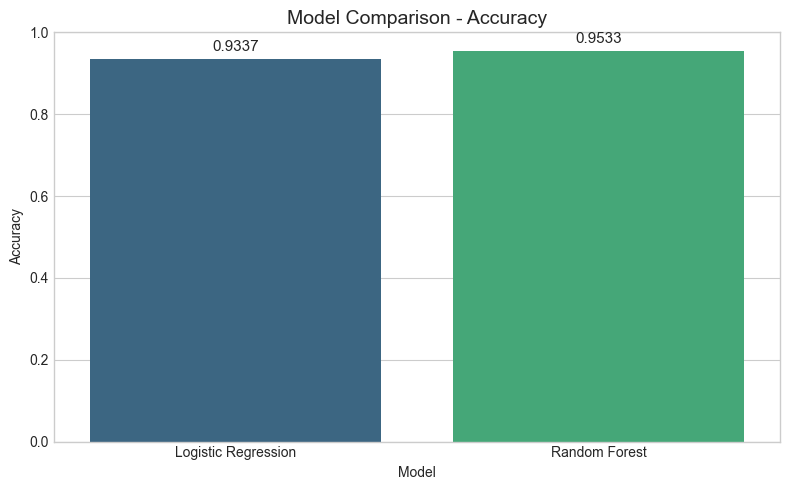


              Model  Accuracy
Logistic Regression  0.933667
      Random Forest  0.953333


In [18]:
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [lr_accuracy, rf_accuracy]
})

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=model_comparison, x='Model', y='Accuracy', ax=ax, palette='viridis')
ax.set_title('Model Comparison - Accuracy', fontsize=14)
ax.set_ylim(0, 1)
for i, v in enumerate(model_comparison['Accuracy']):
    ax.text(i, v + 0.02, f'{v:.4f}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

print("\n" + model_comparison.to_string(index=False))

Top 10 Important Features:
           Feature  Importance
29             INR    0.192726
28   Triglycerides    0.162034
21             ALT    0.116555
22             AST    0.081210
27             GGT    0.062605
11     Sym_Fatigue    0.062303
24         Albumin    0.058578
23       Bilirubin    0.054622
16  Sym_Dark_Urine    0.030207
25       Platelets    0.027369


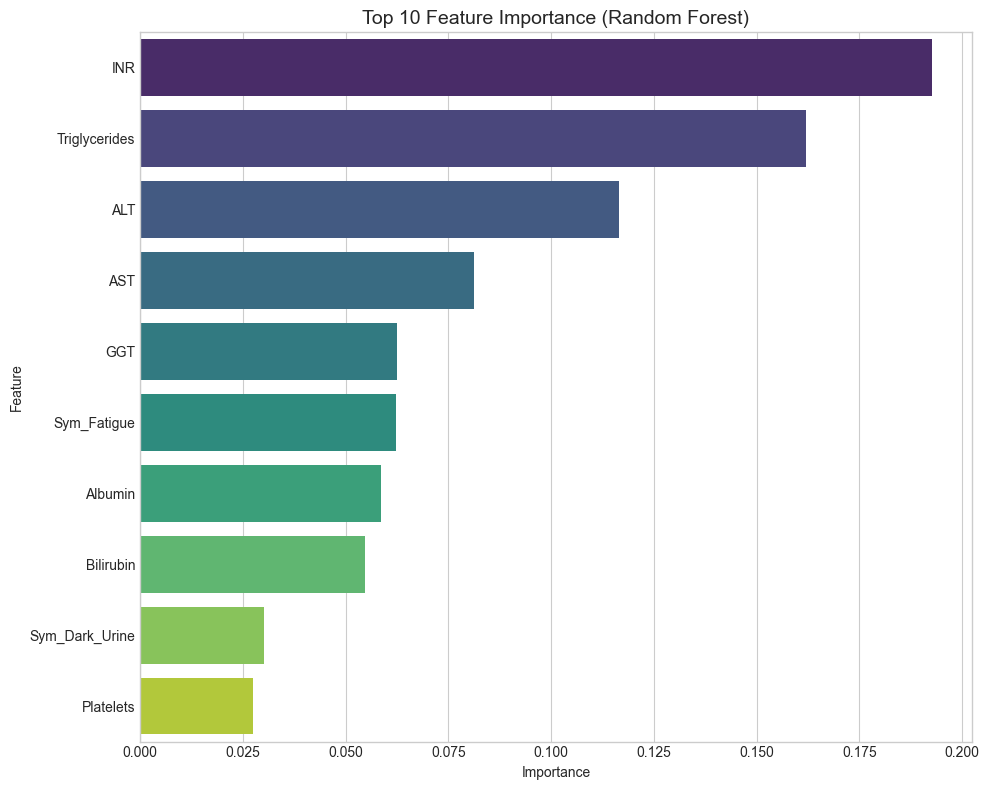

In [19]:
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 10 Important Features:")
print(feature_importance.head(10))

fig, ax = plt.subplots(figsize=(10, 8))
top_features = feature_importance.head(10)
sns.barplot(data=top_features, x='Importance', y='Feature', ax=ax, palette='viridis')
ax.set_title('Top 10 Feature Importance (Random Forest)', fontsize=14)
plt.tight_layout()
plt.show()

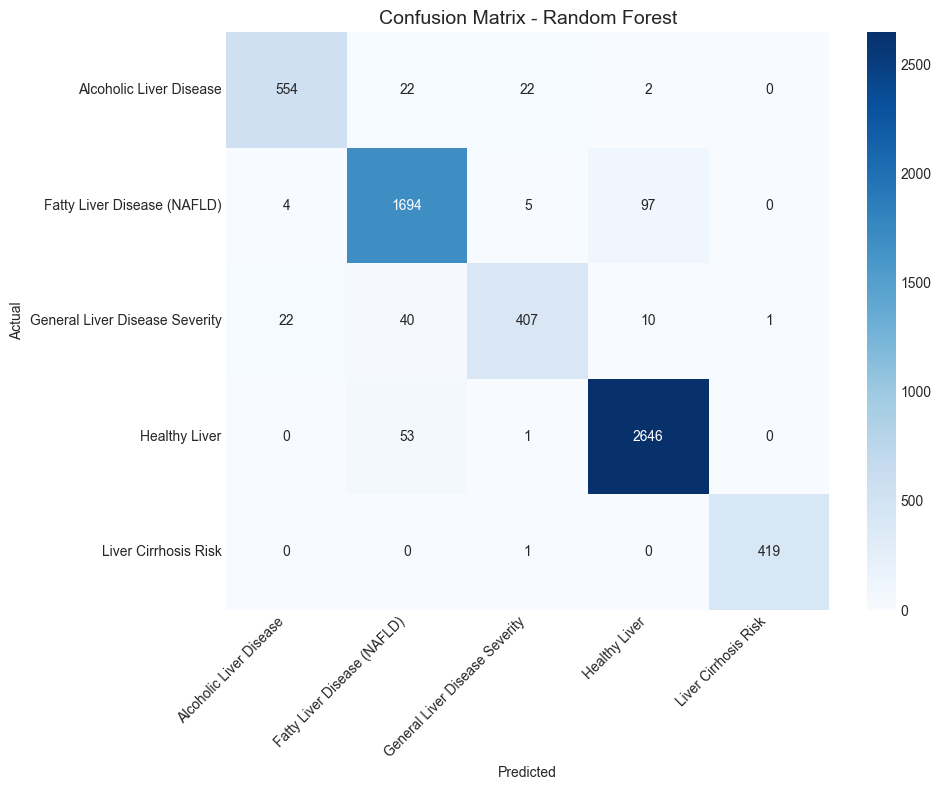

In [20]:
best_model = rf_model
best_pred = rf_pred
best_accuracy = rf_accuracy

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le_target.classes_, 
            yticklabels=le_target.classes_)
plt.title('Confusion Matrix - Random Forest', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Summary

In [21]:
print("=" * 50)
print("ANALYSIS SUMMARY")
print("=" * 50)
print("Dataset:")
print("- Training samples:", df_train.shape[0])
print("- Test samples:", df_test.shape[0])
print("- Features:", len(feature_cols))
print("- Target classes:", len(le_target.classes_))
print("")
print("Best Model: Random Forest")
print("- Test Accuracy:", round(best_accuracy, 4))
print("")
print("Key Findings:")
print("- Lab values (INR, Triglycerides, ALT, AST, Bilirubin, GGT) are important predictors")
print("- Age and comorbidities contribute to predictions")
print("- Random Forest outperforms Logistic Regression")

ANALYSIS SUMMARY
Dataset:
- Training samples: 30000
- Test samples: 5500
- Features: 31
- Target classes: 5

Best Model: Random Forest
- Test Accuracy: 0.9533

Key Findings:
- Lab values (INR, Triglycerides, ALT, AST, Bilirubin, GGT) are important predictors
- Age and comorbidities contribute to predictions
- Random Forest outperforms Logistic Regression
